#recreate the ICA plot from Appendix

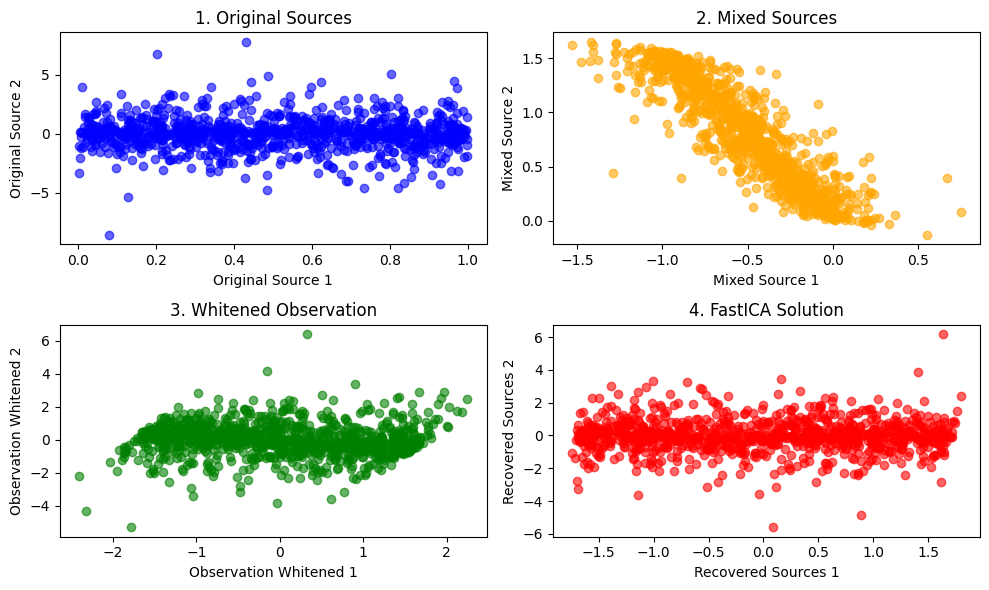

In [1]:
import overcomplete_learning.em as ol_em
import numpy as np
import matplotlib.pyplot as plt
import overcomplete_learning.data as ol_data

rng = np.random.default_rng(1)
n = 1000
S1 = rng.uniform(low=0, high=1, size=(n, 1))
S2 = rng.laplace(size=(n, 1))
A =   rng.normal(size=(2, 2))

S = np.concatenate([S1, S2], axis=1)  # Fixed np.concat to np.concatenate for standard NumPy
X = (A @ S.T).T

# Assuming ol_fastica, ol_data, and ol_em are pre-defined in your environment:
X_whitened, _, _ = ol_data.whiten_canonical(X=X, n_components=2)
sknown = ol_data.make_sknown(S=S, n_known_src=0)
S_sol = ol_em.run_EM_FastICA(
    X=X_whitened, rng=None, S_known=sknown, EM_iter=100, err_tolerance=1e-4
)


# --- Subplot Implementation ---
# Create a 2x2 grid of subplots with a designated figure size
fig, axes = plt.subplots(2, 2, figsize=(10, 6))


# 1. Original Sources (Top-Left)
axes[0, 0].scatter(S[:, 0], S[:, 1], alpha=0.6, color="blue")
axes[0, 0].set_title("1. Original Sources")
axes[0, 0].set_xlabel("Original Source 1")
axes[0, 0].set_ylabel("Original Source 2")

# 2. Mixed Sources (Top-Right)
axes[0, 1].scatter(X[:, 0], X[:, 1], alpha=0.6, color="orange")
axes[0, 1].set_title("2. Mixed Sources")
axes[0, 1].set_xlabel("Mixed Source 1")
axes[0, 1].set_ylabel("Mixed Source 2")

# 3. Whitened Observation (Bottom-Left)
axes[1, 0].scatter(X_whitened[:, 0], X_whitened[:, 1], alpha=0.6, color="green")
axes[1, 0].set_title("3. Whitened Observation")
axes[1, 0].set_xlabel("Observation Whitened 1")
axes[1, 0].set_ylabel("Observation Whitened 2")


B_perm, idx, signs, scales, err = ol_data.best_permutation_match_sign_flips(A = A, B = S_sol['A_est'])



# 4. FastICA Solution (Bottom-Right)
axes[1, 1].scatter(
    S_sol["S_est"][:,idx][:, 0]*np.sign(scales[0]), S_sol["S_est"][:,idx][:, 1]*np.sign(scales[1]), alpha=0.6, color="red"
)
axes[1, 1].set_title("4. FastICA Solution")
axes[1, 1].set_xlabel("Recovered Sources 1")
axes[1, 1].set_ylabel("Recovered Sources 2")

# Automatically adjust padding between subplots to prevent overlapping text
plt.tight_layout()

# Display the final compilation
plt.show()